IMPORT NECCESARY LIBRARY 

In [1]:
%pip install optuna xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, roc_auc_score, roc_curve
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split, KFold, cross_val_score


import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = [12, 8]

CONFIGURE THE INFORMATION OF STOCK 

In [3]:
# Configuration
STOCK_SYMBOL = 'AAPL'  # Change this to analyze different stocks
TIME_PERIOD = '5y'     # Options: '1y', '2y', '5y', 'max'
TEST_SIZE = 0.2        # Percentage of data for testing
RANDOM_STATE = 42      # For reproducible results

print(f"Analyzing: {STOCK_SYMBOL}")
print(f"Time Period: {TIME_PERIOD}")
print(f"Test Size: {TEST_SIZE*100}%")

Analyzing: AAPL
Time Period: 5y
Test Size: 20.0%


=====DATA PREPARATION=====

===Load and clean data===

FETCH THE STOCK DATA THROUGH YAHOO FINANCE LIBRARY

In [4]:
def fetch_stock_data(symbol, period):
    """Fetch stock data from Yahoo Finance"""
    print(f"Fetching data for {symbol}...")
    try:
        stock = yf.Ticker(symbol)
        data = stock.history(period=period)
        print(f"Successfully fetched {len(data)} days of data")
        print(f"Date range: {data.index[0].strftime('%Y-%m-%d')} to {data.index[-1].strftime('%Y-%m-%d')}")
        return data
    except Exception as e:
        print(f"Error fetching data: {e}")
        return None

# Fetch the data
stock_data = fetch_stock_data(STOCK_SYMBOL, TIME_PERIOD)
stock_data.head(n=20)
stock_data.shape

Fetching data for AAPL...
Successfully fetched 1256 days of data
Date range: 2020-08-31 to 2025-08-29
Successfully fetched 1256 days of data
Date range: 2020-08-31 to 2025-08-29


(1256, 7)

In [5]:
# Basic data exploration
print("Dataset Info:")
print(f"Shape: {stock_data.shape}")
print(f"Columns: {list(stock_data.columns)}")
print(f"\nBasic Statistics:")
stock_data.describe()

Dataset Info:
Shape: (1256, 7)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']

Basic Statistics:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1256.000000,1256.000000,1256.000000,1256.000000,1.256000e+03,1256.000000,1256.000000
mean,169.621975,171.509361,167.872345,169.771447,7.556092e+07,0.003734,0.003185
std,36.193915,36.440187,36.027254,36.285477,3.566038e+07,0.029435,0.112867
min,101.687917,107.183774,100.287201,103.925156,2.323470e+07,0.000000,0.000000
25%,141.176504,143.632018,139.941389,142.086933,5.078920e+07,0.000000,0.000000
50%,167.591493,169.139113,166.042080,167.596016,6.781560e+07,0.000000,0.000000
75%,193.467721,194.990376,191.926430,193.258339,9.037062e+07,0.000000,0.000000
max,257.276679,259.179926,256.718662,258.103729,3.326072e+08,0.260000,4.000000


In [6]:
STOCK_DATA_COLUMNS = ['Open', 'High', 'Low', 'Close', 'Volume']
stock_data = stock_data[STOCK_DATA_COLUMNS]
print("\nFiltered Columns:")
stock_data.dropna(inplace=True)  # Drop rows with NaN values
print(stock_data.head(n=20))
print(f"\nData Shape after filtering: {stock_data.shape}")


Filtered Columns:
                                 Open        High         Low       Close  \
Date                                                                        
2020-08-31 00:00:00-04:00  124.099341  127.426034  122.562445  125.519501   
2020-09-01 00:00:00-04:00  129.138014  131.122367  126.968858  130.519272   
2020-09-02 00:00:00-04:00  133.836227  134.215586  123.535150  127.815102   
2020-09-03 00:00:00-04:00  123.447633  125.324972  117.212508  117.582138   
2020-09-04 00:00:00-04:00  116.794232  120.325195  107.864682  117.659950   
2020-09-08 00:00:00-04:00  110.841180  115.743679  109.605832  109.742012   
2020-09-09 00:00:00-04:00  114.060871  115.889578  112.115436  114.119232   
2020-09-10 00:00:00-04:00  117.076312  117.212491  109.430749  110.393738   
2020-09-11 00:00:00-04:00  111.444274  112.086271  106.998954  108.944389   
2020-09-14 00:00:00-04:00  111.590184  112.767172  109.722568  112.212723   
2020-09-15 00:00:00-04:00  115.101701  115.588060  110.51

ADD MORE FEATURES - TECHNICAL INDICATORS 

In [7]:

#calculation technical indicators 

def calculate_rsi(prices, period=14):
    """Calculate Relative Strength Index (RSI)"""
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# ema, sma 
def calculate_moving_averages(data):
    """Calculate various moving averages"""
    data['MA_5'] = data['Close'].rolling(window=5).mean()
    data['MA_10'] = data['Close'].rolling(window=10).mean()
    data['MA_20'] = data['Close'].rolling(window=20).mean()
    return data

# use above function to calculate technical indicators
def calculate_technical_indicators(data):
    """Calculate all technical indicators"""
    df = data.copy()
    
    # Moving averages
    df = calculate_moving_averages(df)
    
    # RSI
    df['RSI'] = calculate_rsi(df['Close'], 14)
    
    # Other indicators
    df['Price_Change'] = df['Close'].pct_change()
    df['Volatility'] = df['Close'].rolling(window=10).std()
    df['High_Low_Ratio'] = df['High'] / df['Low']
    
    return df

# Apply technical indicators
stock_data_with_indicators = calculate_technical_indicators(stock_data)
print("Technical indicators added!")
stock_data_with_indicators[['Close', 'MA_5', 'MA_10', 'MA_20', 'RSI']].head(10)
stock_data_with_indicators.head(10)

# as null values is exists need to drop null values
print("\nTechnical Indicators Summary:")

stock_data_with_indicators.dropna(inplace=True)  # Drop NaN values after calculations

stock_data_with_indicators.head(10)
print(stock_data_with_indicators.shape)

Technical indicators added!

Technical Indicators Summary:
(1237, 12)


CREATE THE TARGET FEATURES FOR MDOELS TRAINING 

In [8]:
def create_features(data):
    """Create all features for the model"""
    df = data.copy()
    
    # Previous values (lag features) mean down one units as previous results 
    df['Prev_Close'] = df['Close'].shift(1)
    df['Prev_Volume'] = df['Volume'].shift(1)
    df['Prev_High'] = df['High'].shift(1)
    df['Prev_Low'] = df['Low'].shift(1)
    
    # Volume features
    df['Volume_MA'] = df['Volume'].rolling(window=10).mean()
    df['Volume_Ratio'] = df['Volume'] / df['Volume_MA']
    
    # Price ratios
    df['Close_MA5_Ratio'] = df['Close'] / df['MA_5']
    
    # Multiple lag features
    for i in range(1, 6):
        df[f'Close_Lag_{i}'] = df['Close'].shift(i)
        df[f'Volume_Lag_{i}'] = df['Volume'].shift(i)
    
    # Target variable (next day's closing price)
    df['Target_Return'] = df['Close'].pct_change().shift(-1)
    df['Target_Return'] = (df['Target_Return'] > 0).astype(int)
    
    df["Target"] = df['Close'].shift(-1)  # Predict next day's closing price

    return df

# Create features
feature_data = create_features(stock_data_with_indicators)
print("Features created!")
print(f"Dataset shape after feature engineering: {feature_data.shape}")

feature_data.dropna(inplace=True)  # Drop rows with NaN values
print("\nFeature data after dropping NaN values:")

print(feature_data.shape)
feature_data.head()

Features created!
Dataset shape after feature engineering: (1237, 31)

Feature data after dropping NaN values:
(1227, 31)


,Open,High,Low,Close,Volume,MA_5,MA_10,MA_20,RSI,Price_Change,...,Close_Lag_2,Volume_Lag_2,Close_Lag_3,Volume_Lag_3,Close_Lag_4,Volume_Lag_4,Close_Lag_5,Volume_Lag_5,Target_Return,Target
Date,,,,,,,,,,,,,,,,,,,,,
2020-10-09 00:00:00-04:00,112.134913,113.807989,111.784734,113.778809,100506900,112.189386,111.993865,109.969151,60.616342,0.017396,...,111.940361,96849000.0,110.072762,161498200.0,113.321625,106243800.0,109.936554,144712000.0,1,121.006104
2020-10-12 00:00:00-04:00,116.784504,121.764822,116.025785,121.006104,240226800,113.726282,112.912112,110.408820,66.500657,0.063521,...,111.833374,83477200.0,111.940361,96849000.0,110.072762,161498200.0,113.321625,106243800.0,0,117.796135
2020-10-13 00:00:00-04:00,121.852367,121.969096,116.385697,117.796135,262330500,115.270956,113.593989,110.679235,69.015242,-0.026527,...,113.778809,100506900.0,111.833374,83477200.0,111.940361,96849000.0,110.072762,161498200.0,1,117.883667
2020-10-14 00:00:00-04:00,117.698848,119.673464,116.356500,117.883667,150712000,116.459618,114.117310,111.119877,68.139869,0.000743,...,121.006104,240226800.0,113.778809,100506900.0,111.833374,83477200.0,111.940361,96849000.0,0,117.416771
2020-10-15 00:00:00-04:00,115.481064,117.893401,114.926616,117.416771,112559200,117.576297,114.498616,111.624232,63.102279,-0.003961,...,117.796135,262330500.0,121.006104,240226800.0,113.778809,100506900.0,111.833374,83477200.0,0,115.772881


KEY INSIGHT OF THE DATA 

VISUALIZATION THE STOCK DATA THROUGH USING PYPLOT

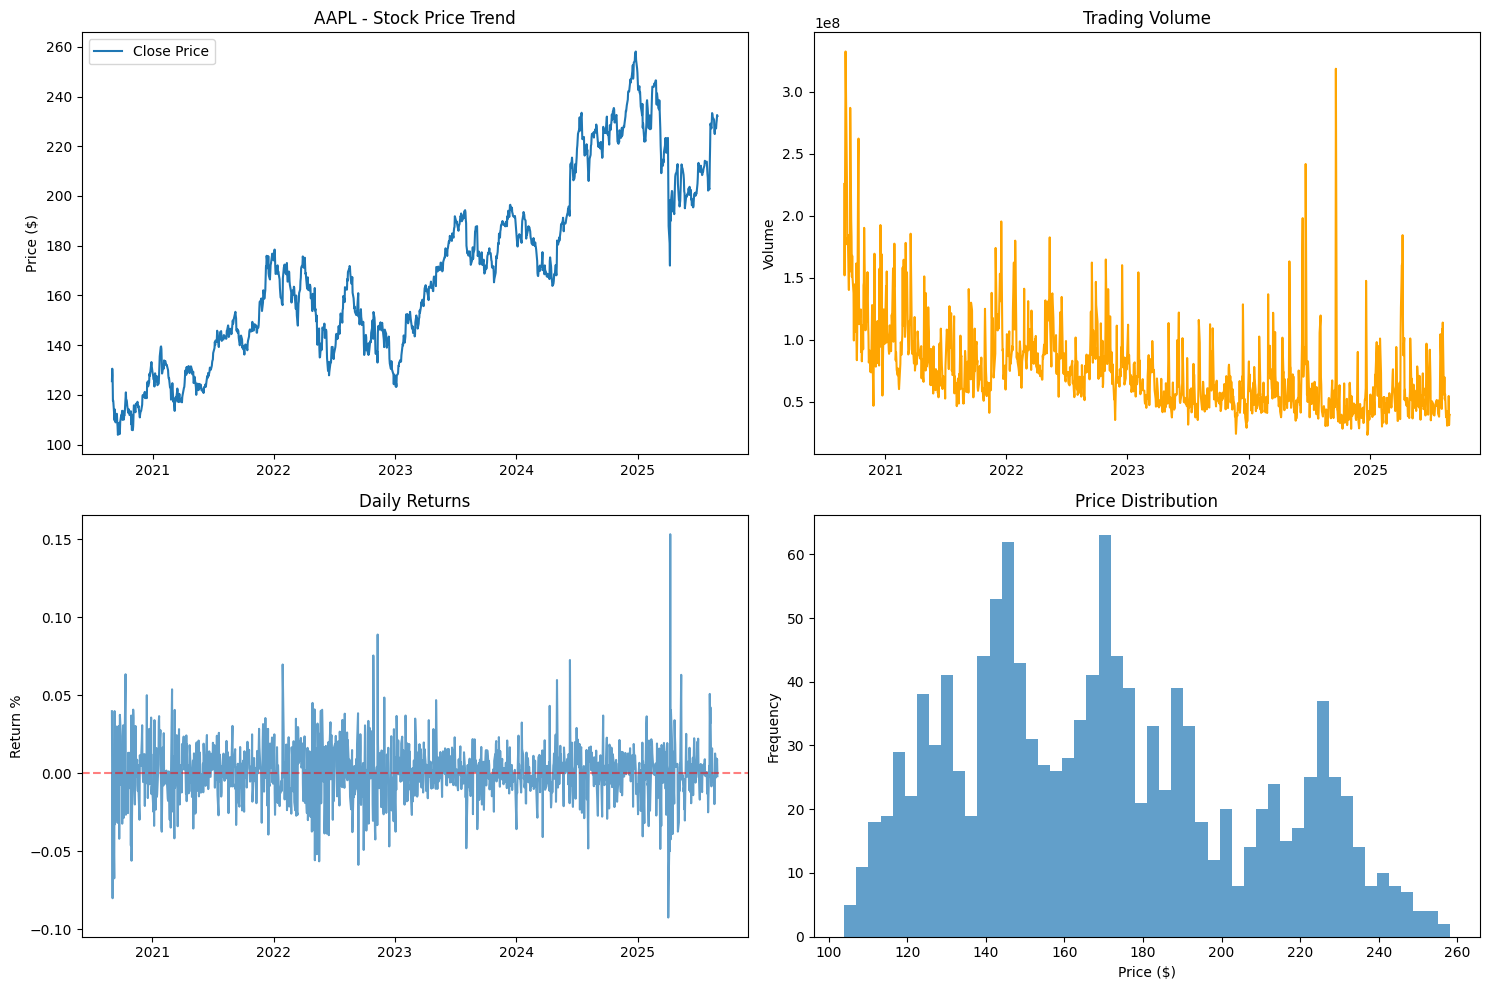

In [9]:
# Plot stock price trends
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Price trends
axes[0,0].plot(stock_data.index, stock_data['Close'], label='Close Price')
axes[0,0].set_title(f'{STOCK_SYMBOL} - Stock Price Trend')
axes[0,0].set_ylabel('Price ($)')
axes[0,0].legend()

# Volume
axes[0,1].plot(stock_data.index, stock_data['Volume'], color='orange')
axes[0,1].set_title('Trading Volume')
axes[0,1].set_ylabel('Volume')

# Daily returns
daily_returns = stock_data['Close'].pct_change()
axes[1,0].plot(stock_data.index, daily_returns, alpha=0.7)
axes[1,0].set_title('Daily Returns')
axes[1,0].set_ylabel('Return %')
axes[1,0].axhline(y=0, color='r', linestyle='--', alpha=0.5)

# Price distribution
axes[1,1].hist(stock_data['Close'], bins=50, alpha=0.7)
axes[1,1].set_title('Price Distribution')
axes[1,1].set_xlabel('Price ($)')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

VISUALIZATION THE TECHNICAL INDICATORS 

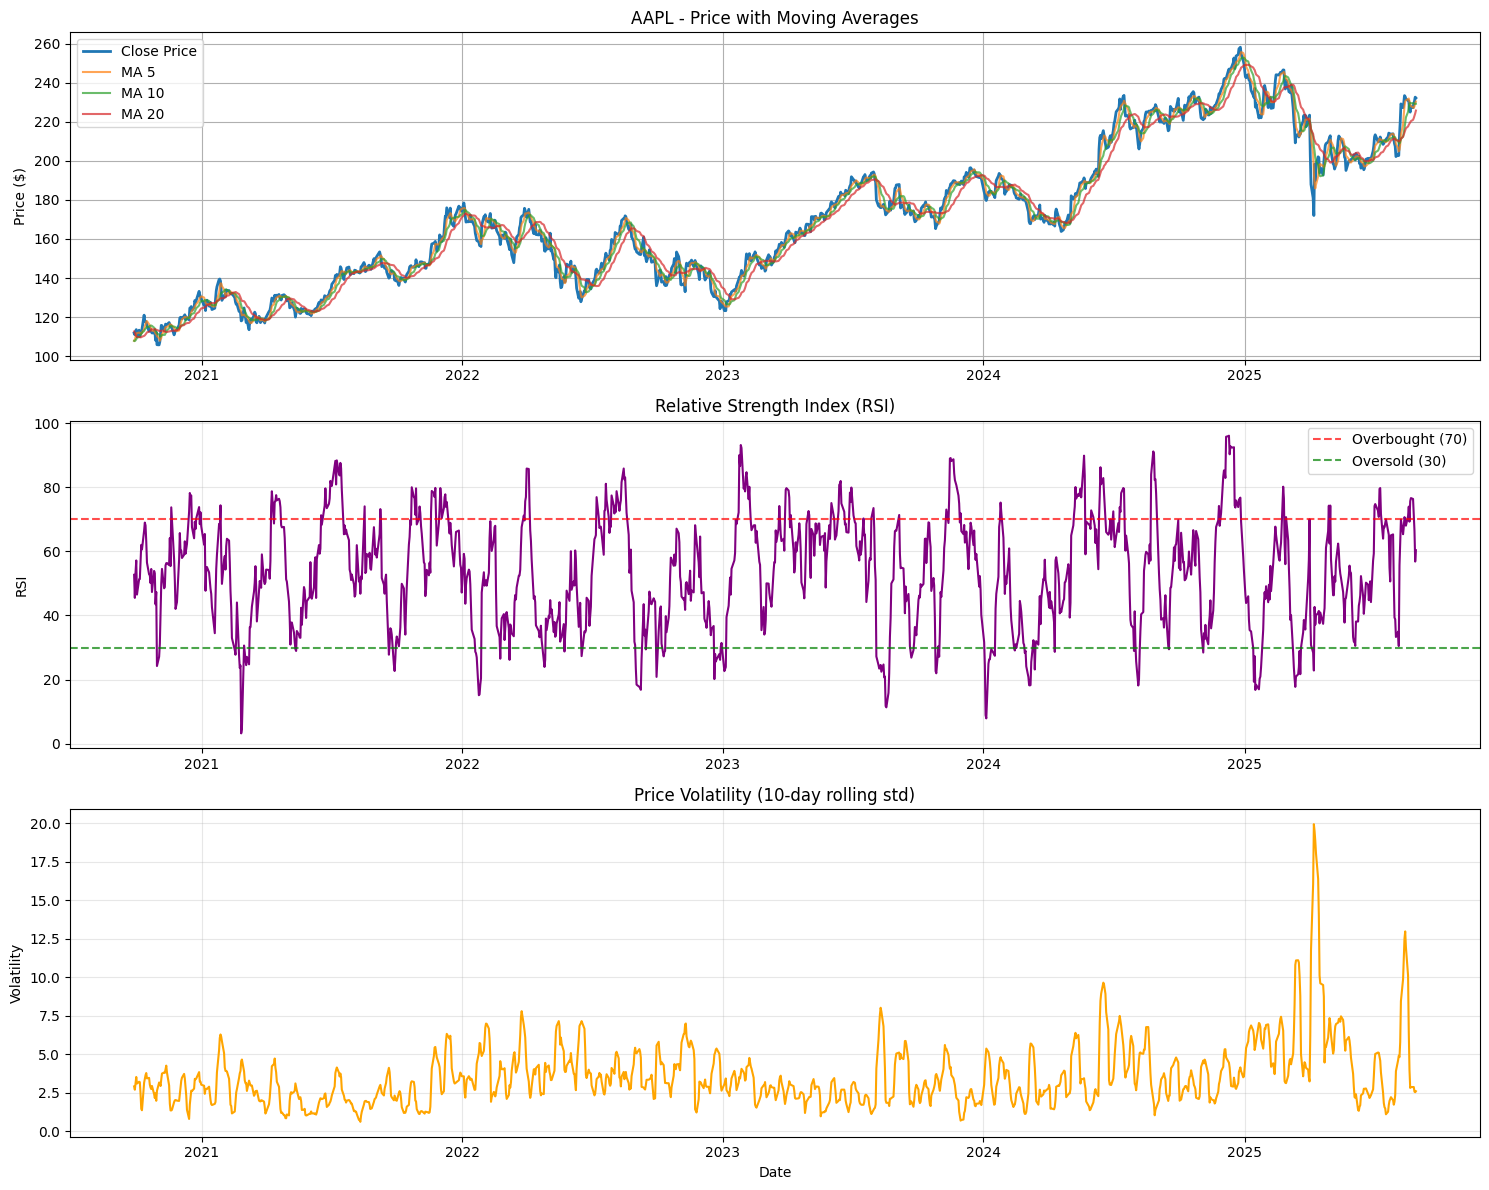

In [10]:
# Plot technical indicators
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Price with moving averages
axes[0].plot(stock_data_with_indicators.index, stock_data_with_indicators['Close'], label='Close Price', linewidth=2)
axes[0].plot(stock_data_with_indicators.index, stock_data_with_indicators['MA_5'], label='MA 5', alpha=0.7)
axes[0].plot(stock_data_with_indicators.index, stock_data_with_indicators['MA_10'], label='MA 10', alpha=0.7)
axes[0].plot(stock_data_with_indicators.index, stock_data_with_indicators['MA_20'], label='MA 20', alpha=0.7)
axes[0].set_title(f'{STOCK_SYMBOL} - Price with Moving Averages')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=1.0)

# RSI
axes[1].plot(stock_data_with_indicators.index, stock_data_with_indicators['RSI'], color='purple')
axes[1].axhline(y=70, color='r', linestyle='--', alpha=0.7, label='Overbought (70)')
axes[1].axhline(y=30, color='g', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[1].set_title('Relative Strength Index (RSI)')
axes[1].set_ylabel('RSI')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Volatility
axes[2].plot(stock_data_with_indicators.index, stock_data_with_indicators['Volatility'], color='orange')
axes[2].set_title('Price Volatility (10-day rolling std)')
axes[2].set_ylabel('Volatility')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

IDENTIFY TREANDS AND ANOMALIES 

PREPROCESSING STOCK DATA FOR MODELS TRAINING

In [11]:
#preprocessing this data for model training
# Define the target variable
# Define features for the model
model_features = [
    'Prev_Close', 'Prev_Volume', 'Prev_High', 'Prev_Low',
    'MA_5', 'MA_10', 'MA_20', 'RSI', 'Price_Change', 'Volatility',
    'High_Low_Ratio', 'Close_MA5_Ratio', 'Volume_Ratio',
    'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_4', 'Close_Lag_5',
    'Volume_Lag_1', 'Volume_Lag_2', 'Volume_Lag_3', 'Volume_Lag_4', 'Volume_Lag_5'
]

# Remove rows with NaN values
clean_data = feature_data.dropna()

# Prepare features and target
X = clean_data[model_features]
y = clean_data['Target_Return']
z = clean_data['Target']


print(f"Clean dataset shape: {clean_data.shape}")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target shape: {z.shape}")
print(f"Date range: {clean_data.index[0].strftime('%Y-%m-%d')} to {clean_data.index[-1].strftime('%Y-%m-%d')}")

# Check for any remaining NaN values
print(f"\nNaN values in features: {X.isnull().sum().sum()}")
print(f"NaN values in target: {y.isnull().sum()}")
print(f"NaN values in target: {z.isnull().sum()}")

Clean dataset shape: (1227, 31)
Features shape: (1227, 23)
Target shape: (1227,)
Target shape: (1227,)
Date range: 2020-10-09 to 2025-08-28

NaN values in features: 0
NaN values in target: 0
NaN values in target: 0


SPLIT THE DATA INTO TRAINING DATA AND TEST DATA 

In [12]:
# Split data (using time-based split, not random)
X_train, X_test, z_train, z_test = train_test_split(
    X, z, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=False
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Training period: {X_train.index[0].strftime('%Y-%m-%d')} to {X_train.index[-1].strftime('%Y-%m-%d')}")
print(f"Testing period: {X_test.index[0].strftime('%Y-%m-%d')} to {X_test.index[-1].strftime('%Y-%m-%d')}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeature scaling completed!")
print(f"Training features mean: {X_train_scaled.mean():.6f}")
print(f"Training features std: {X_train_scaled.std():.6f}")

Training set: 981 samples
Testing set: 246 samples
Training period: 2020-10-09 to 2024-09-04
Testing period: 2024-09-05 to 2025-08-28

Feature scaling completed!
Training features mean: 0.000000
Training features std: 1.000000


=============================================================================================================================================

START TO TRAINING MODELS (MODELS TRAINING)
1) Linear Regression 
2) Decision Tree Regressor
3) Support Vector Regressor
4) XGBoost Models 
  

SELECT MODEL BASED ON BASED ON TITLE 

In [13]:
# Initialize and train the model
lr_model = LinearRegression()
print("Training Linear Regression model...")

# Fit the model
lr_model.fit(X_train_scaled, z_train)

# Make predictions
train_predictions = lr_model.predict(X_train_scaled)
test_predictions = lr_model.predict(X_test_scaled)

print("Model training completed!")
print(f"Model intercept: {lr_model.intercept_:.4f}")
print(f"Number of features: {len(lr_model.coef_)}")

Training Linear Regression model...
Model training completed!
Model intercept: 158.4491
Number of features: 23


In [14]:
# Calculate evaluation metrics Linear Regression
def evaluate_predictions(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    

    print(f"{dataset_name} Set Metrics:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  R²:   {r2:.4f}")
    print()

    return {'rmse': rmse, 'mae': mae, 'r2': r2}

print("=" * 50)
print("MODEL EVALUATION RESULTS")
print("=" * 50)


# call function to evaluate predictions
train_metrics = evaluate_predictions(z_train, train_predictions, "Training")
test_metrics = evaluate_predictions(z_test, test_predictions, "Testing")


# Calculate percentage accuracy
train_mape = np.mean(np.abs((z_train - train_predictions) / z_train)) * 100
test_mape = np.mean(np.abs((z_test - test_predictions) / z_test)) * 100

print(f"Training MAPE: {train_mape:.2f}%")
print(f"Testing MAPE: {test_mape:.2f}%")
print("=" * 50)

MODEL EVALUATION RESULTS
Training Set Metrics:
  RMSE: 2.66
  MAE:  1.98
  R²:   0.9902

Testing Set Metrics:
  RMSE: 4.16
  MAE:  2.79
  R²:   0.9334

Training MAPE: 1.28%
Testing MAPE: 1.29%


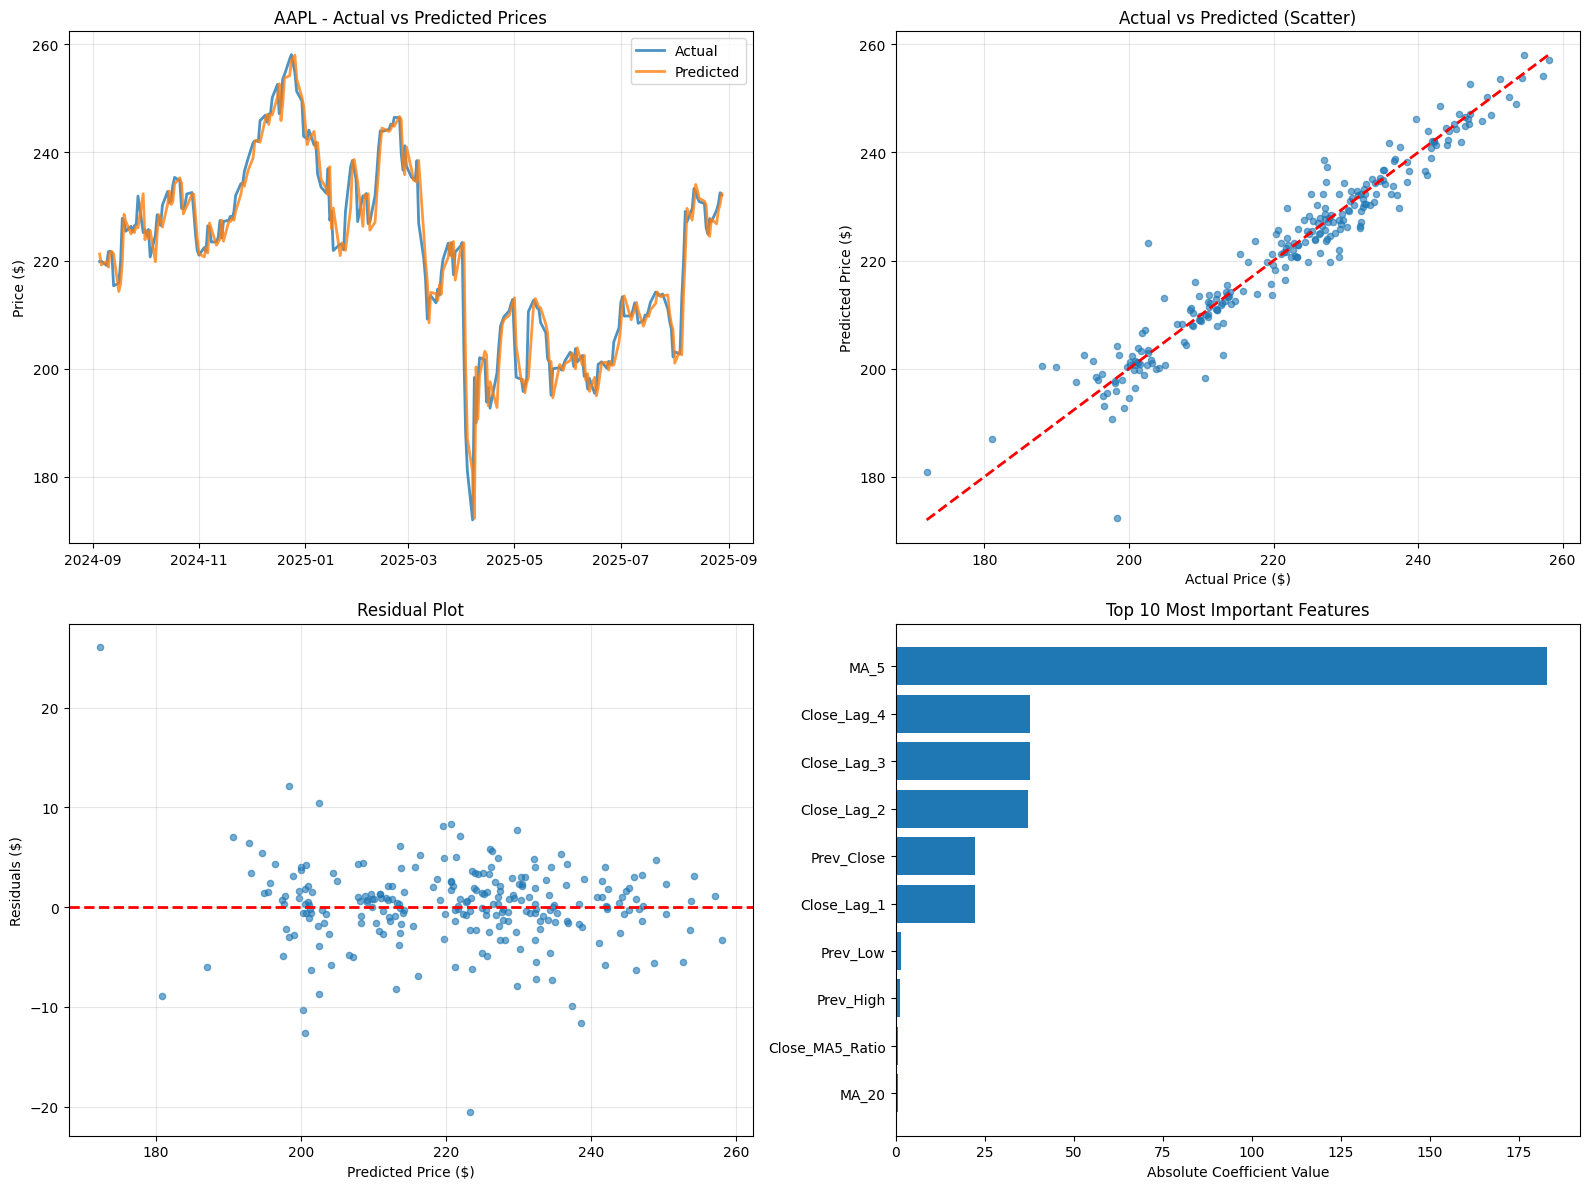

In [15]:
# Comprehensive results visualization (Linear Regression)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Time series comparison
axes[0, 0].plot(z_test.index, z_test.values, label='Actual', linewidth=2, alpha=0.8)
axes[0, 0].plot(z_test.index, test_predictions, label='Predicted', linewidth=2, alpha=0.8)
axes[0, 0].set_title(f'{STOCK_SYMBOL} - Actual vs Predicted Prices')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Scatter plot
axes[0, 1].scatter(z_test, test_predictions, alpha=0.6, s=20)
min_price = min(z_test.min(), test_predictions.min())
max_price = max(z_test.max(), test_predictions.max())
axes[0, 1].plot([min_price, max_price], [min_price, max_price], 'r--', linewidth=2)
axes[0, 1].set_xlabel('Actual Price ($)')
axes[0, 1].set_ylabel('Predicted Price ($)')
axes[0, 1].set_title('Actual vs Predicted (Scatter)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals
residuals = z_test - test_predictions
axes[1, 0].scatter(test_predictions, residuals, alpha=0.6, s=20)
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Price ($)')
axes[1, 0].set_ylabel('Residuals ($)')
axes[1, 0].set_title('Residual Plot')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Feature importance
feature_importance = abs(lr_model.coef_)
indices = np.argsort(feature_importance)[-10:]  # Top 10
axes[1, 1].barh(range(len(indices)), feature_importance[indices])
axes[1, 1].set_yticks(range(len(indices)))
axes[1, 1].set_yticklabels([model_features[i] for i in indices])
axes[1, 1].set_xlabel('Absolute Coefficient Value')
axes[1, 1].set_title('Top 10 Most Important Features')


plt.tight_layout()
plt.show()

In [16]:
# Initialize and train the model

print("Training Decision Tree Regressor model...")

dt_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)

# Fit the model
dt_model.fit(X_train_scaled, z_train)

# Make predictions
dt_train_predictions = dt_model.predict(X_train_scaled)
dt_test_predictions  = dt_model.predict(X_test_scaled)

print("Decision Tree training completed!")
print(f"Tree Depth: {dt_model.get_depth()}")
print(f"Number of Leaves: {dt_model.get_n_leaves()}")


Training Decision Tree Regressor model...
Decision Tree training completed!
Tree Depth: 5
Number of Leaves: 31


In [17]:
# Evaluation Decision Tree
def evaluate_predictions_with_mape(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{dataset_name} Set Metrics:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    print()
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}


print("\n" + "=" * 50)
print("DECISION TREE EVALUATION RESULTS")
print("=" * 50)

dt_train_metrics = evaluate_predictions_with_mape(z_train, dt_train_predictions, "Training")
dt_test_metrics  = evaluate_predictions_with_mape(z_test,  dt_test_predictions,  "Testing")


DECISION TREE EVALUATION RESULTS
Training Set Metrics:
  RMSE: 3.19
  MAE:  2.46
  R²:   0.9858
  MAPE: 1.58%

Testing Set Metrics:
  RMSE: 14.72
  MAE:  11.88
  R²:   0.1663
  MAPE: 5.34%



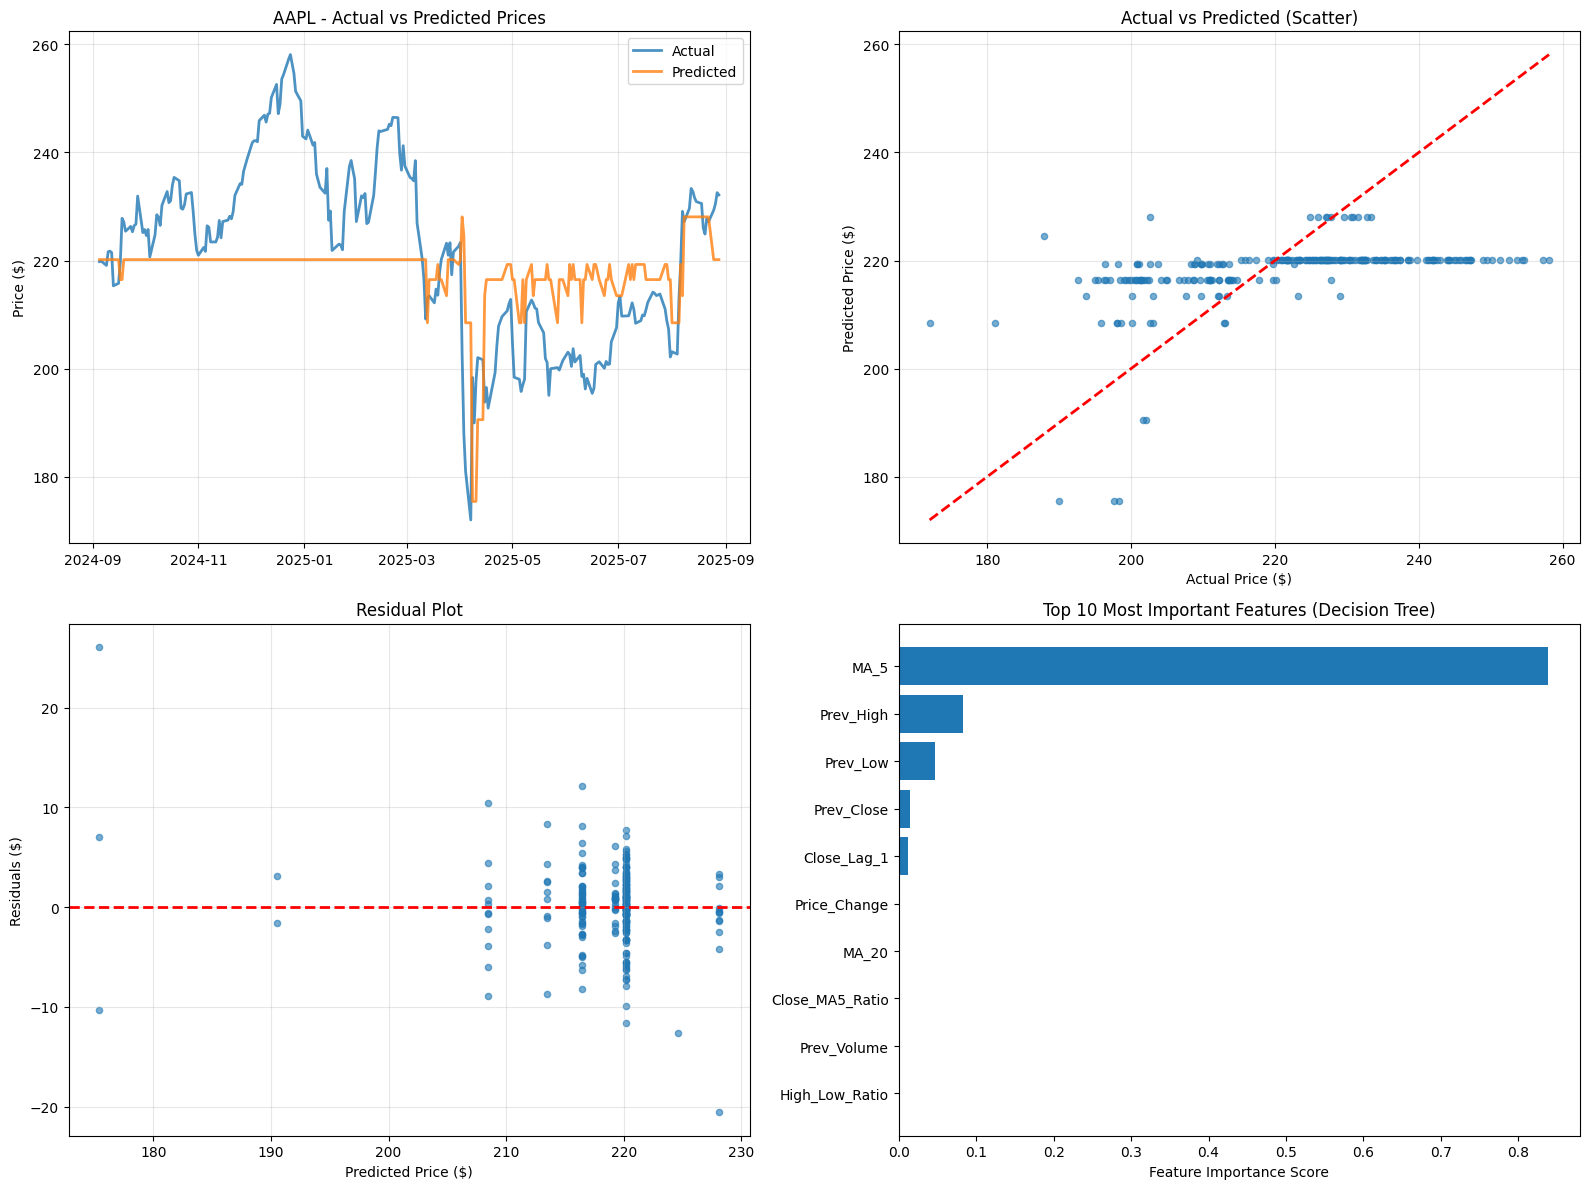

In [18]:
# Comprehensive results visualization（decesion tree）
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Time series comparison
axes[0, 0].plot(z_test.index, z_test.values, label='Actual', linewidth=2, alpha=0.8)
axes[0, 0].plot(z_test.index, dt_test_predictions, label='Predicted', linewidth=2, alpha=0.8)
axes[0, 0].set_title(f'{STOCK_SYMBOL} - Actual vs Predicted Prices')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Scatter plot
axes[0, 1].scatter(z_test, dt_test_predictions, alpha=0.6, s=20)
min_price = min(z_test.min(), dt_test_predictions.min())
max_price = max(z_test.max(), dt_test_predictions.max())
axes[0, 1].plot([min_price, max_price], [min_price, max_price], 'r--', linewidth=2)
axes[0, 1].set_xlabel('Actual Price ($)')
axes[0, 1].set_ylabel('Predicted Price ($)')
axes[0, 1].set_title('Actual vs Predicted (Scatter)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals
residuals = z_test - test_predictions
axes[1, 0].scatter(dt_test_predictions, residuals, alpha=0.6, s=20)
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Price ($)')
axes[1, 0].set_ylabel('Residuals ($)')
axes[1, 0].set_title('Residual Plot')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Feature importance
feature_importance = dt_model.feature_importances_   # decision tree
indices = np.argsort(feature_importance)[-10:]      # Top 10
axes[1, 1].barh(range(len(indices)), feature_importance[indices])
axes[1, 1].set_yticks(range(len(indices)))
axes[1, 1].set_yticklabels([model_features[i] for i in indices])
axes[1, 1].set_xlabel('Feature Importance Score')
axes[1, 1].set_title('Top 10 Most Important Features (Decision Tree)')


plt.tight_layout()
plt.show()

In [19]:
# Initialize and train the model (SVR)

print("\n" + "=" * 50)
print("Training Support Vector Regression model...")
print("=" * 50)

# You can tune parameters: kernel, C, epsilon, gamma
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1, gamma=0.1)

# Fit the model
svr_model.fit(X_train_scaled, z_train)

# Make predictions
svr_train_predictions = svr_model.predict(X_train_scaled)
svr_test_predictions  = svr_model.predict(X_test_scaled)

print("SVR training completed!")


Training Support Vector Regression model...
SVR training completed!
SVR training completed!


In [20]:
# Evaluation SVR
def evaluate_predictions_with_mape(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{dataset_name} Set Metrics:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    print()
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}


print("\n" + "=" * 50)
print("SVR EVALUATION RESULTS")
print("=" * 50)

svr_train_metrics = evaluate_predictions_with_mape(z_train, svr_train_predictions, "Training")
svr_test_metrics  = evaluate_predictions_with_mape(z_test,  svr_test_predictions,  "Testing" )


SVR EVALUATION RESULTS
Training Set Metrics:
  RMSE: 0.78
  MAE:  0.29
  R²:   0.9992
  MAPE: 0.18%

Testing Set Metrics:
  RMSE: 32.00
  MAE:  23.76
  R²:   -2.9397
  MAPE: 10.31%



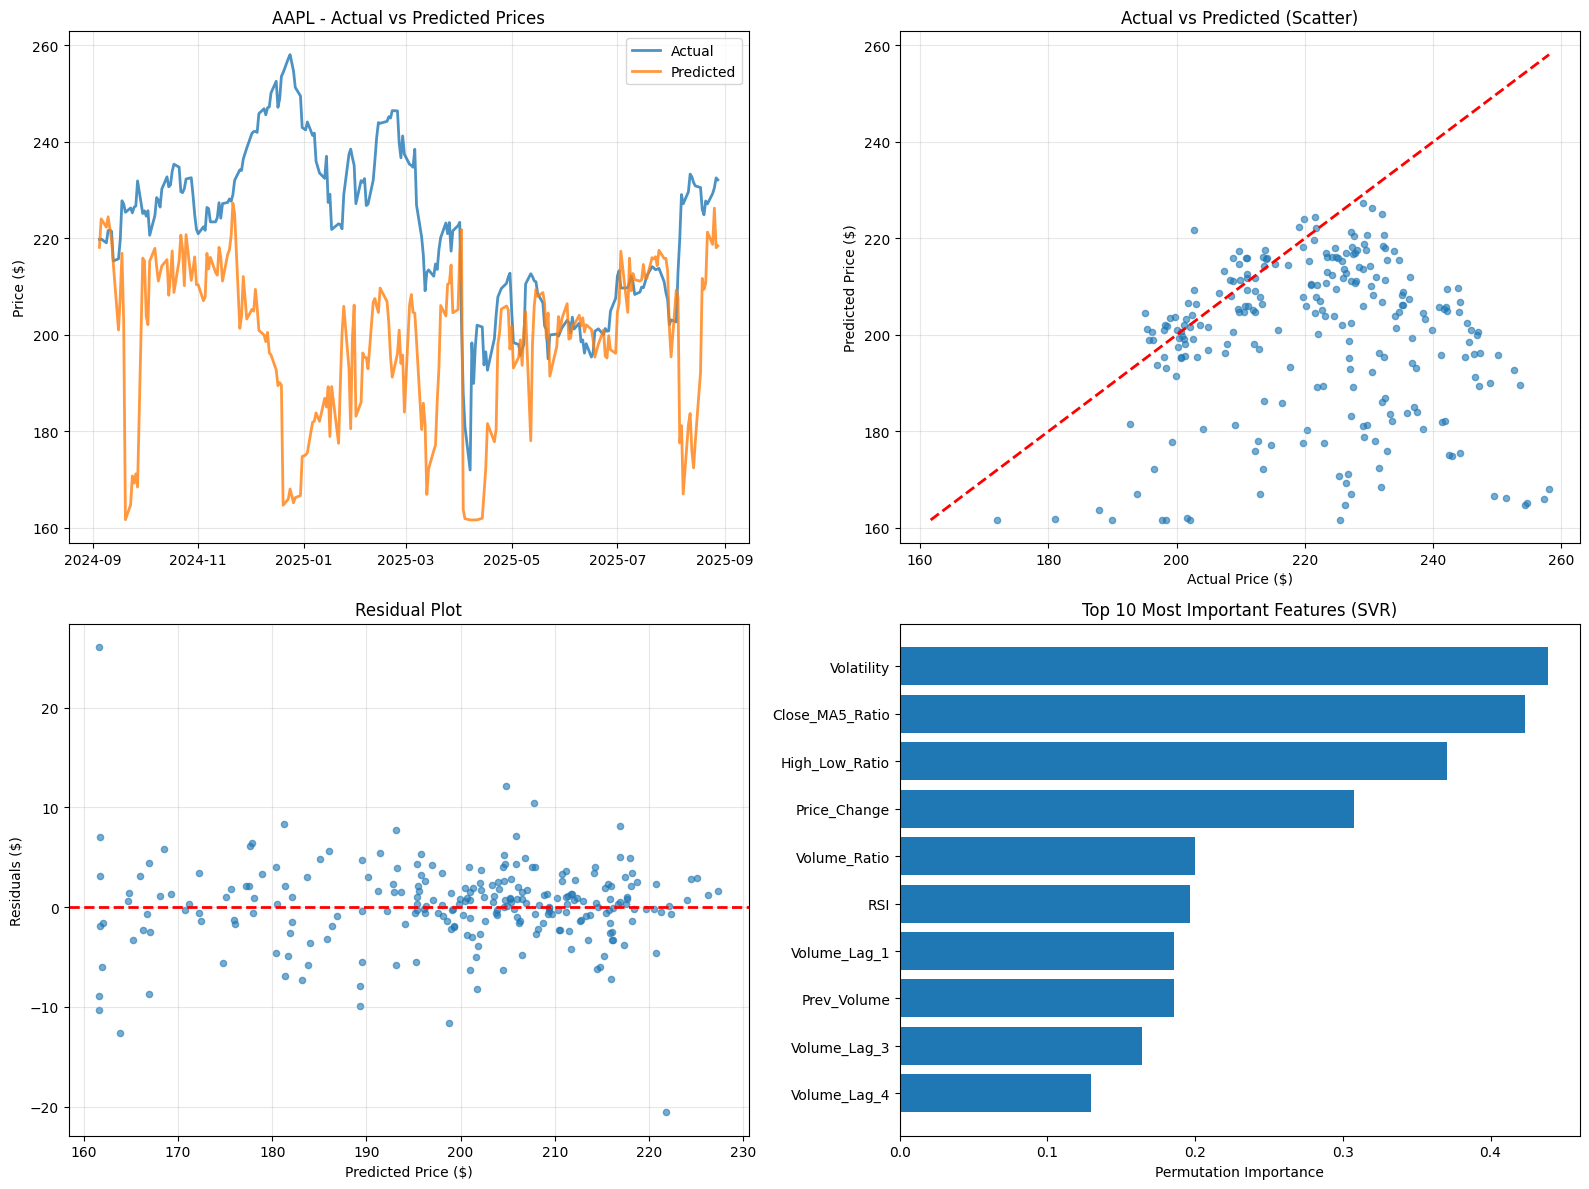

In [21]:
# Comprehensive results visualization（Support Vector Regressor）
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Time series comparison
axes[0, 0].plot(z_test.index, z_test.values, label='Actual', linewidth=2, alpha=0.8)
axes[0, 0].plot(z_test.index, svr_test_predictions, label='Predicted', linewidth=2, alpha=0.8)
axes[0, 0].set_title(f'{STOCK_SYMBOL} - Actual vs Predicted Prices')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Scatter plot
axes[0, 1].scatter(z_test, svr_test_predictions, alpha=0.6, s=20)
min_price = min(z_test.min(), svr_test_predictions.min())
max_price = max(z_test.max(), svr_test_predictions.max())
axes[0, 1].plot([min_price, max_price], [min_price, max_price], 'r--', linewidth=2)
axes[0, 1].set_xlabel('Actual Price ($)')
axes[0, 1].set_ylabel('Predicted Price ($)')
axes[0, 1].set_title('Actual vs Predicted (Scatter)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals
residuals = z_test - test_predictions
axes[1, 0].scatter(svr_test_predictions, residuals, alpha=0.6, s=20)
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Price ($)')
axes[1, 0].set_ylabel('Residuals ($)')
axes[1, 0].set_title('Residual Plot')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Feature importance
from sklearn.inspection import permutation_importance

# compute permutation importance
perm_importance = permutation_importance(svr_model, X_test_scaled, z_test, n_repeats=20, random_state=42)

feature_importance = perm_importance.importances_mean
indices = np.argsort(feature_importance)[-10:]   # Top 10
axes[1, 1].barh(range(len(indices)), feature_importance[indices])
axes[1, 1].set_yticks(range(len(indices)))
axes[1, 1].set_yticklabels([model_features[i] for i in indices])
axes[1, 1].set_xlabel('Permutation Importance')
axes[1, 1].set_title('Top 10 Most Important Features (SVR)')


plt.tight_layout()
plt.show()

In [22]:
# xgboost with optuna hyperparameter tuning
import optuna
from sklearn.metrics import f1_score
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import numpy as np

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.4, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 10, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "use_label_encoder": False,
        "tree_method": "hist",  
        "random_state": 42,
    }

    model = xgb.XGBClassifier(**params)


    cv = TimeSeriesSplit(n_splits=5)
    f1_scores = []

    for train_idx, test_idx in cv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]   

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        f1_scores.append(f1_score(y_test, preds))

    return np.mean(f1_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)  

best_params = study.best_params
print("Best Parameters:", best_params)



[I 2025-09-01 00:44:17,424] A new study created in memory with name: no-name-7e6c8a84-d196-4ebf-b9db-843db01e3da9
[I 2025-09-01 00:44:20,129] Trial 0 finished with value: 0.4958719339376188 and parameters: {'n_estimators': 526, 'learning_rate': 0.23900578592233393, 'max_depth': 9, 'subsample': 0.5741515936613067, 'colsample_bytree': 0.5383053523533405, 'reg_alpha': 0.06374575775812874, 'reg_lambda': 0.0025651166715109155, 'min_child_weight': 10}. Best is trial 0 with value: 0.4958719339376188.
[I 2025-09-01 00:44:20,129] Trial 0 finished with value: 0.4958719339376188 and parameters: {'n_estimators': 526, 'learning_rate': 0.23900578592233393, 'max_depth': 9, 'subsample': 0.5741515936613067, 'colsample_bytree': 0.5383053523533405, 'reg_alpha': 0.06374575775812874, 'reg_lambda': 0.0025651166715109155, 'min_child_weight': 10}. Best is trial 0 with value: 0.4958719339376188.
[I 2025-09-01 00:44:26,928] Trial 1 finished with value: 0.4252533482671844 and parameters: {'n_estimators': 618, 'l

Best Parameters: {'n_estimators': 249, 'learning_rate': 0.001112108051127557, 'max_depth': 6, 'subsample': 0.6539824727829855, 'colsample_bytree': 0.9728411331603697, 'reg_alpha': 9.737899896517535, 'reg_lambda': 8.794533041928561, 'min_child_weight': 3}



===== Model Evaluation Results =====
Accuracy : 0.5265
Precision: 0.5265
Recall   : 1.0000
F1-score : 0.6898
ROC-AUC  : 0.7535

===== Classification Report =====
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00       581
          Up       0.53      1.00      0.69       646

    accuracy                           0.53      1227
   macro avg       0.26      0.50      0.34      1227
weighted avg       0.28      0.53      0.36      1227



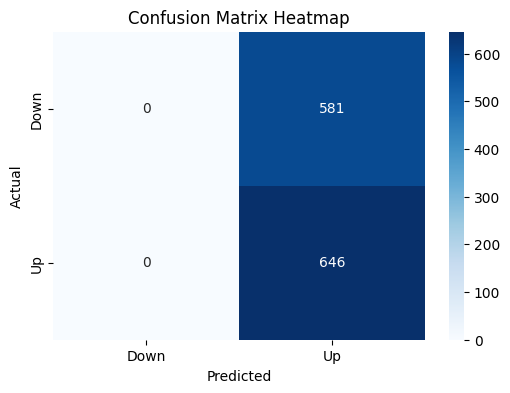

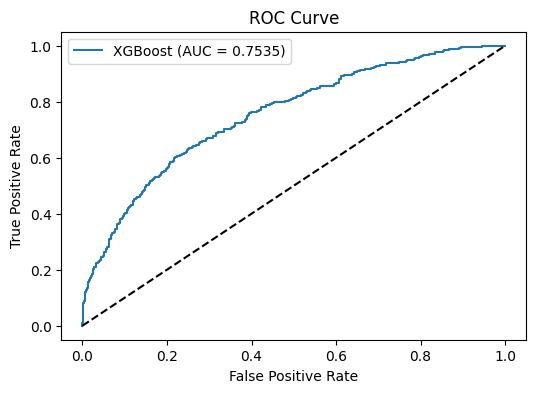

In [23]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# Final Model Training
# ======================
xgb_model = xgb.XGBClassifier(**best_params)
xgb_model.fit(X, y)

# Predict
y_pred = xgb_model.predict(X)
y_proba = xgb_model.predict_proba(X)[:, 1]  # for ROC/AUC

# ======================
# Metrics
# ======================
acc = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred)
rec = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
auc = roc_auc_score(y, y_proba)

print("\n===== Model Evaluation Results =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\n===== Classification Report =====")
print(classification_report(y, y_pred, target_names=["Down", "Up"]))

# ======================
# Confusion Matrix Heatmap
# ======================
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

# ======================
# ROC Curve
# ======================
fpr, tpr, thresholds = roc_curve(y, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--")  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


START TO PREDICT NEXT RADING DAY STOCK DATA PRICE 

In [24]:
# Predict next trading day
def predict_next_day(model, scaler, features, current_data):
    """Predict the next trading day's closing price"""
    # Use the last available data point
    last_features = features.iloc[-1:].values
    last_features_scaled = scaler.transform(last_features)
    
    prediction = model.predict(last_features_scaled)[0]
    current_price = current_data['Close'].iloc[-1]
    
    return prediction, current_price

# Make next day prediction
next_prediction, current_price = predict_next_day(xgb_model, scaler, X, clean_data)

print("=" * 60)
print(f"NEXT DAY PREDICTION FOR {STOCK_SYMBOL}")
print("=" * 60)
print(f"Current Price: ${current_price:.2f}")
print(f"Predicted Price: ${next_prediction:.2f}")
print(f"Expected Change: ${next_prediction - current_price:.2f}")
print(f"Expected Change %: {((next_prediction - current_price) / current_price) * 100:.2f}%")

if next_prediction > current_price:
    print("📈 Prediction: BULLISH (Price expected to rise)")
else:
    print("📉 Prediction: BEARISH (Price expected to fall)")
    
print("=" * 60)

NEXT DAY PREDICTION FOR AAPL
Current Price: $232.56
Predicted Price: $1.00
Expected Change: $-231.56
Expected Change %: -99.57%
📉 Prediction: BEARISH (Price expected to fall)


FUNCTION OF QUICK DEPLOY FOR ANALYSIS STOCK PRICE USING LR 

In [25]:
# main function to run quick analysis
# Quick analysis for different stocks
def quick_analysis(symbol, period='1y'):
    """Run quick analysis for any stock"""
    print(f"\n{'='*50}")
    print(f"Quick Analysis: {symbol}")
    print(f"{'='*50}")
    
    # Fetch data
    data = fetch_stock_data(symbol, period)
    if data is None:
        return
    
    # Create features
    data_with_indicators = calculate_technical_indicators(data)
    feature_data = create_features(data_with_indicators)
    clean_data = feature_data.dropna()
    
    # Prepare data - FIXED: Use correct target column name
    X = clean_data[model_features]
    y = clean_data['Target']  # Changed from 'Next_Close' to 'Target'
    
    # Split and scale
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    test_predictions = model.predict(X_test_scaled)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
    mae = mean_absolute_error(y_test, test_predictions)
    r2 = r2_score(y_test, test_predictions)
    
    print(f"RMSE: ${rmse:.2f}")
    print(f"MAE: ${mae:.2f}")
    print(f"R²: {r2:.4f}")
    
    # Next day prediction - FIXED: Use the correct model (LinearRegression, not XGBoost)
    next_pred, current = predict_next_day(model, scaler, X, clean_data)
    change = ((next_pred - current) / current) * 100
    print(f"Current: ${current:.2f} → Predicted: ${next_pred:.2f} ({change:+.2f}%)")

# Analyze different stocks
stocks_to_analyze = ['TSLA', 'GOOGL', 'MSFT', 'AMZN']
for stock in stocks_to_analyze:
    quick_analysis(stock, '1y')


Quick Analysis: TSLA
Fetching data for TSLA...
Successfully fetched 250 days of data
Date range: 2024-08-30 to 2025-08-29
RMSE: $9.51
MAE: $7.32
R²: 0.5532
Current: $345.98 → Predicted: $347.22 (+0.36%)

Quick Analysis: GOOGL
Fetching data for GOOGL...
Successfully fetched 250 days of data
Date range: 2024-08-30 to 2025-08-29
RMSE: $2.91
MAE: $2.29
R²: 0.9325
Current: $211.64 → Predicted: $210.35 (-0.61%)

Quick Analysis: MSFT
Fetching data for MSFT...
Successfully fetched 250 days of data
Date range: 2024-08-30 to 2025-08-29
RMSE: $5.73
MAE: $4.02
R²: 0.7103
Current: $509.64 → Predicted: $508.17 (-0.29%)

Quick Analysis: AMZN
Fetching data for AMZN...
RMSE: $9.51
MAE: $7.32
R²: 0.5532
Current: $345.98 → Predicted: $347.22 (+0.36%)

Quick Analysis: GOOGL
Fetching data for GOOGL...
Successfully fetched 250 days of data
Date range: 2024-08-30 to 2025-08-29
RMSE: $2.91
MAE: $2.29
R²: 0.9325
Current: $211.64 → Predicted: $210.35 (-0.61%)

Quick Analysis: MSFT
Fetching data for MSFT...
Suc